# 03 · Fuente de datos de imágenes (Fase 2)

Este notebook ejercita, de forma **aislada**, el módulo que transforma las fotos en tensores:
`diffusion.data_generation.infinite_batches`. Es la fuente de datos de la **Fase 2** (imágenes) y
entrega **exactamente el mismo contrato** que la fuente toy-2D del swiss roll —un *iterador infinito
de tensores crudos*— pero con imágenes en lugar de puntos:

$$\text{batch} \in \mathbb{R}^{(B,\,3,\,64,\,64)}, \quad \text{float32}, \quad \text{valores en } [-1, 1].$$

No toca SDE, red ni entrenamiento: es **pura fuente de datos**. Acá lo corremos sobre
`data/cats-prueba/` (2 gatos de prueba) para ver el contrato de salida, la higiene report-only, y las
dos decisiones configurables —**augmentation** (volteo horizontal) y **encuadre** (center-crop vs
deform)—, más la garantía de reproducibilidad por `seed`.

> Requiere `torchvision` en el kernel (está en el `.venv` del proyecto: `torchvision 0.27.0+cpu`).
> Usá el mismo kernel que los notebooks `01`/`02`.

In [1]:
# --- Setup: bootstrap de sys.path + imports + helpers de ploteo ---
import sys
import pathlib

# El pythonpath del pyproject solo aplica a pytest, no al kernel de Jupyter:
# ubicamos a mano la raiz del paquete (la carpeta que contiene src/diffusion).
_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontre src/diffusion subiendo desde {_here}")
_src = str((_root / "src").resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

from diffusion.data_generation import infinite_batches, report_small_images
from diffusion.data_generation.images import IMAGE_EXTENSIONS

plt.rcParams.update({"figure.dpi": 110})

CATS = _root / "data" / "cats-prueba"
n_imgs = sum(
    1 for p in CATS.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)

print("paquete en:", _root)
print("torchvision:", torchvision.__version__, "| torch:", torch.__version__)
print("carpeta      :", CATS)
print("imagenes     :", n_imgs)


def denorm(batch):
    """[-1, 1] -> [0, 1] y (B,3,H,W) -> (B,H,W,3) numpy, listo para imshow."""
    x = (batch * 0.5 + 0.5).clamp(0.0, 1.0)
    return x.permute(0, 2, 3, 1).cpu().numpy()


def show_grid(batch, ncols=8, title=None, cell=1.6):
    """Dibuja un batch (B,3,H,W) en [-1,1] como grilla de imagenes."""
    imgs = denorm(batch)
    n = len(imgs)
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(cell * ncols, cell * nrows), squeeze=False)
    for k, ax in enumerate(axes.flat):
        ax.axis("off")
        if k < n:
            ax.imshow(imgs[k])
    if title:
        fig.suptitle(title, y=1.0, fontsize=12)
    fig.tight_layout()
    plt.show()

paquete en: c:\Users\bravo\Facultad\calculo-estocastico\tp-final\diffusion-models
torchvision: 0.27.0+cpu | torch: 2.12.0+cpu
carpeta      : c:\Users\bravo\Facultad\calculo-estocastico\tp-final\diffusion-models\data\cats-prueba
imagenes     : 2


## 1. Higiene *report-only* (pre-entrenamiento)

`report_small_images` recorre la carpeta y **reporta** (no borra ni modifica nada) las imágenes cuyo
**lado corto** cae por debajo de `min_size` —justo las que el `Resize` tendría que *ampliar* (upscale)
y entrarían borrosas al modelo—. Está separada del flujo de carga: es un chequeo que se corre a mano
antes de entrenar. El **dedup** no es de este módulo (vive en `scripts/limpiar_imagenes.py`).

Los 2 gatos de prueba son exactamente 64×64, así que con `min_size=64` no se reporta ninguno
(64 no es `< 64`). El chequeo se vuelve relevante cuando la carpeta trae fotos de tamaños arbitrarios.

In [2]:
small = report_small_images(CATS, min_size=64, verbose=True)
print(f"imagenes con lado corto < 64 px: {len(small)} (report-only, no se borro nada)")

# Subiendo el umbral, el mismo chequeo ya las marca (demuestra que el criterio corre):
print("con min_size=128:", len(report_small_images(CATS, min_size=128)), "de", n_imgs)

imagenes con lado corto < 64 px: 0 (report-only, no se borro nada)
con min_size=128: 2 de 2


## 2. El contrato de salida — iterador infinito de tensores crudos

`infinite_batches(root, batch_size, *, image_size=64, augment=True, crop=True, ...)` devuelve un
**iterador infinito**. Cada `next()` entrega un **tensor pelado** (no una tupla) de shape
`(batch_size, 3, image_size, image_size)`, `float32`, con valores en `[-1, 1]`. Todos los batches
tienen tamaño exacto (`drop_last=True`), y el iterador **nunca se agota**: al terminar de recorrer las
imágenes, vuelve a empezar. Es *drop-in* para el parámetro `data` del `train` genérico.

In [3]:
it = infinite_batches(CATS, batch_size=2, image_size=64,
                      augment=False, num_workers=0, seed=0)
batch = next(it)

print("tipo         :", type(batch).__name__, "(tensor pelado, no tupla)")
print("shape        :", tuple(batch.shape))
print("dtype        :", batch.dtype)
print("rango        : [%.3f, %.3f]" % (float(batch.min()), float(batch.max())))
print("media / std  : %.3f / %.3f" % (float(batch.mean()), float(batch.std())))

assert tuple(batch.shape) == (2, 3, 64, 64)
assert batch.dtype == torch.float32
assert float(batch.min()) >= -1.001 and float(batch.max()) <= 1.001

# Infinito: pedimos mas batches que imagenes/batch_size y nunca corta (no StopIteration).
shapes = [tuple(next(it).shape) for _ in range(5)]
print("\n5 batches mas (nunca se agota):", shapes)

tipo         : Tensor (tensor pelado, no tupla)
shape        : (2, 3, 64, 64)
dtype        : torch.float32
rango        : [-1.000, 1.000]
media / std  : -0.118 / 0.372

5 batches mas (nunca se agota): [(2, 3, 64, 64), (2, 3, 64, 64), (2, 3, 64, 64), (2, 3, 64, 64), (2, 3, 64, 64)]


## 3. Ver las imágenes (des-normalización)

Para *mirar* el batch hay que deshacer la normalización: `[-1, 1] → [0, 1]` con `x*0.5 + 0.5`. Ojo:
esa des-normalización es responsabilidad del **notebook / sampling / eval**, **no** del módulo de
datos —el módulo entrega `[-1, 1]` a propósito, porque es el rango que espera el prior del forward
SDE—. El helper `show_grid` (definido arriba) hace el `denorm` + `imshow`.

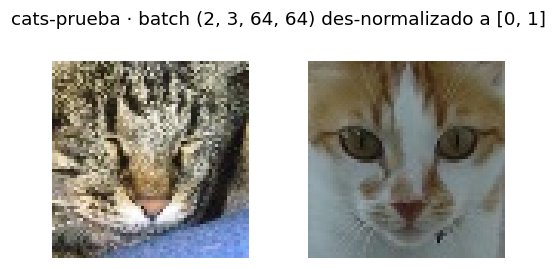

In [4]:
show_grid(batch, ncols=2, title="cats-prueba · batch (2, 3, 64, 64) des-normalizado a [0, 1]", cell=2.4)

## 4. Augmentation — volteo horizontal (`augment`)

Con `augment=True` la cadena antepone `RandomHorizontalFlip(p=0.5)`: cada imagen sale volteada
izquierda-derecha la mitad de las veces. Es el **único** augment (no hay volteos verticales ni
rotaciones: un gato al revés no es una muestra válida de la distribución). Con `augment=False` no se
aplica ningún volteo —salida apta para inspección/validación—.

Para verlo, pedimos el **mismo gato** varias veces (`batch_size=1`, `shuffle=False` → cicla 0001, 0002,
0001, …) y comparamos las dos filas: con `augment=True` algunos salen espejados; con `augment=False`,
ninguno.

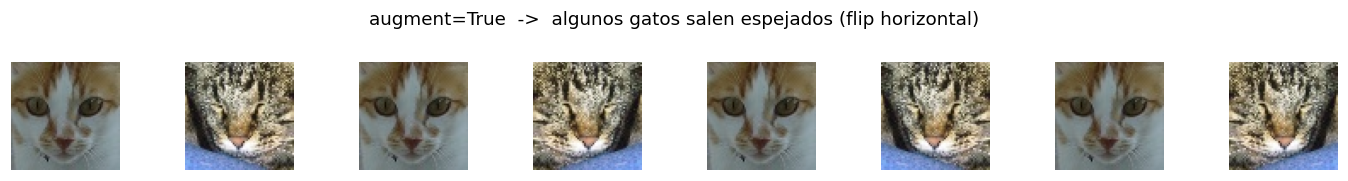

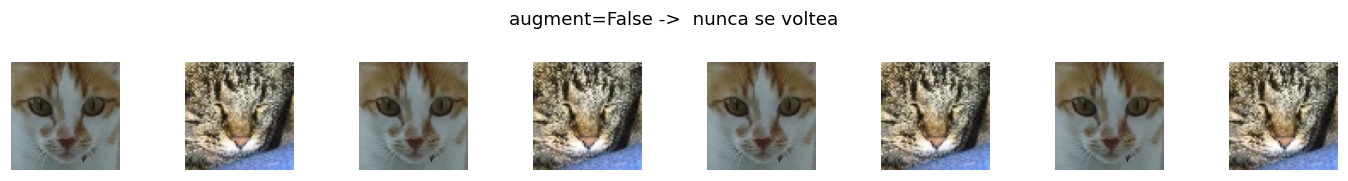

In [5]:
torch.manual_seed(0)  # el flip usa el RNG global; lo fijamos para reproducir la figura
it_aug = infinite_batches(CATS, batch_size=1, augment=True, shuffle=False, num_workers=0)
row_aug = torch.cat([next(it_aug) for _ in range(8)], dim=0)

it_noaug = infinite_batches(CATS, batch_size=1, augment=False, shuffle=False, num_workers=0)
row_noaug = torch.cat([next(it_noaug) for _ in range(8)], dim=0)

show_grid(row_aug,   ncols=8, title="augment=True  ->  algunos gatos salen espejados (flip horizontal)")
show_grid(row_noaug, ncols=8, title="augment=False ->  nunca se voltea")

## 5. Encuadre / framing — `crop=True` (center-crop) vs `crop=False` (deform)

- **`crop=True`** (por defecto): preserva el *aspect ratio* — escala el **lado corto** a `image_size`
  y recorta el centro al cuadrado (`Resize` + `CenterCrop`). Los círculos siguen redondos; se pierden
  los bordes.
- **`crop=False`**: redimensiona directo a `image_size × image_size`, **deformando** la imagen
  (aplasta el eje largo). No se pierde nada, pero cambia las proporciones.

Los gatos de prueba ya son 64×64 (cuadrados), así que sobre *ellos* las dos opciones dan lo mismo. Para
que la diferencia se **vea**, la ilustramos sobre una imagen **no cuadrada** sintética (un círculo
sobre un lienzo ancho 160×64).

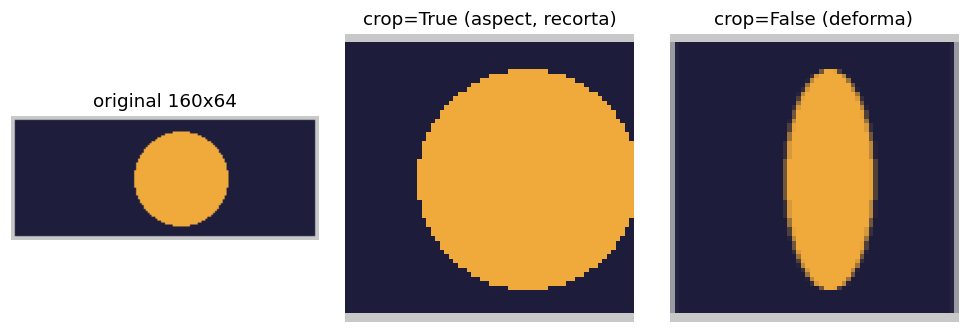

In [6]:
import tempfile
from PIL import Image, ImageDraw

tmp = pathlib.Path(tempfile.mkdtemp(prefix="framing_"))
canvas = Image.new("RGB", (160, 64), (30, 30, 60))
d = ImageDraw.Draw(canvas)
d.ellipse([64, 8, 112, 56], fill=(240, 170, 60))   # circulo centrado (redondo en el original)
d.rectangle([0, 0, 159, 63], outline=(200, 200, 200), width=2)
canvas.save(tmp / "wide.png")

b_crop   = next(infinite_batches(tmp, batch_size=1, image_size=64, augment=False,
                                 crop=True,  shuffle=False, num_workers=0))
b_deform = next(infinite_batches(tmp, batch_size=1, image_size=64, augment=False,
                                 crop=False, shuffle=False, num_workers=0))

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(np.asarray(canvas)); axes[0].set_title("original 160x64")
axes[1].imshow(denorm(b_crop)[0]);   axes[1].set_title("crop=True (aspect, recorta)")
axes[2].imshow(denorm(b_deform)[0]); axes[2].set_title("crop=False (deforma)")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

## 6. Reproducibilidad por `seed`

Con `seed` fijo, `augment=False` y `num_workers=0`, el barajado del `DataLoader` es determinístico:
dos iteradores con la misma `seed` entregan **la misma secuencia** de batches; con `seed` distinta,
no.

In [7]:
a = next(infinite_batches(CATS, batch_size=2, augment=False, num_workers=0, seed=0))
b = next(infinite_batches(CATS, batch_size=2, augment=False, num_workers=0, seed=0))
c = next(infinite_batches(CATS, batch_size=2, augment=False, num_workers=0, seed=1))

print("seed 0 == seed 0 :", torch.equal(a, b))   # True
print("seed 0 == seed 1 :", torch.equal(a, c))   # normalmente False (orden distinto)

seed 0 == seed 0 : True
seed 0 == seed 1 : False


## 7. Fail-fast — errores claros, sin cuelgues

La función valida **antes** de devolver el iterador (no es un generador perezoso): si la carpeta no
existe, está vacía, o tiene **menos imágenes que `batch_size`** (con `drop_last=True` el loader
quedaría vacío y el `while True` giraría sin entregar nada), levanta `ValueError` en el acto.

In [8]:
def expect_valueerror(label, fn):
    try:
        fn()
    except ValueError as e:
        print(f"OK  {label}: ValueError -> {str(e).splitlines()[0][:80]}")
    else:
        print(f"XX  {label}: no levanto (deberia)")

expect_valueerror("carpeta inexistente",
                  lambda: infinite_batches(_root / "no_existe", batch_size=2))
expect_valueerror("batch_size > n_imagenes",
                  lambda: infinite_batches(CATS, batch_size=99))

OK  carpeta inexistente: ValueError -> La carpeta raíz de imágenes no existe: c:\Users\bravo\Facultad\calculo-estocasti
OK  batch_size > n_imagenes: ValueError -> La carpeta c:\Users\bravo\Facultad\calculo-estocastico\tp-final\diffusion-models


## 8. Un batch real más grande (`cats-v1`, opcional)

Si está el set real `data/cats-v1/` (miles de gatos, ya pre-escalados a 64×64), armamos una grilla de
16 con `augment=True` para ver un batch de entrenamiento de verdad. Si no está, se saltea.

cats-v1: 9304 imagenes | batch (16, 3, 64, 64) en [-1.00, 1.00]
higiene <64 px: 0 de 9304


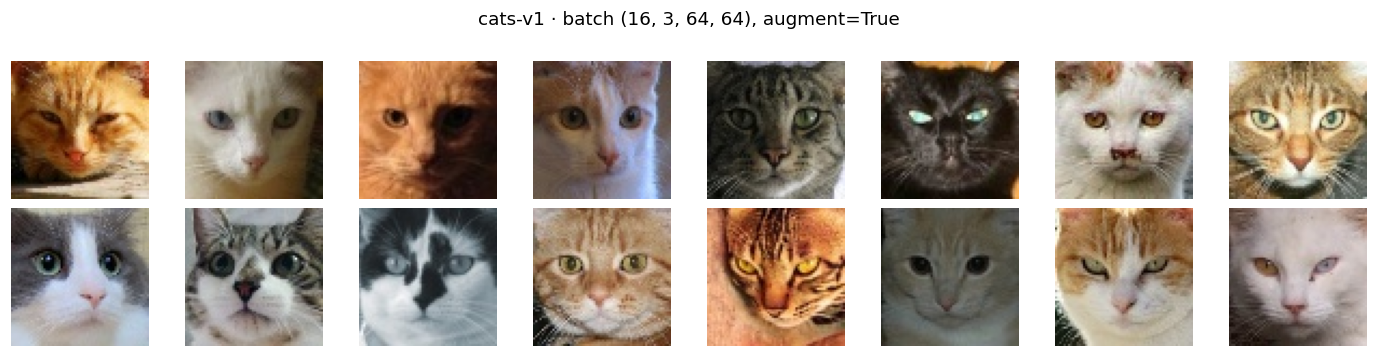

In [9]:
v1 = _root / "data" / "cats-v1"
if v1.is_dir():
    n_v1 = sum(1 for p in v1.rglob("*")
               if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
    big = next(infinite_batches(v1, batch_size=16, image_size=64,
                                augment=True, num_workers=0, seed=1))
    print(f"cats-v1: {n_v1} imagenes | batch {tuple(big.shape)} en "
          f"[{float(big.min()):.2f}, {float(big.max()):.2f}]")
    print("higiene <64 px:", len(report_small_images(v1, min_size=64)), "de", n_v1)
    show_grid(big, ncols=8, title=f"cats-v1 · batch (16, 3, 64, 64), augment=True")
else:
    print("data/cats-v1/ no esta; se saltea (la demo principal corre sobre cats-prueba).")

## Cierre

`infinite_batches` produce **el mismo contrato** que consume `train` (iterador infinito de tensores
crudos), ahora con imágenes `(B, 3, 64, 64)` en `[-1, 1]`. La red (`ScoreUNet`) y el `train`
model-agnóstico ya lo pueden recibir.

**Pendiente (fuera de este módulo):** el camino de entrenamiento de imágenes de punta a punta todavía
está bloqueado —`sde.perturb`/`score_target` y los samplers asumen estado vector `(B, data_dim)` y no
operan aún sobre tensores `(B, C, H, W)`—; generalizarlos es una spec futura (ver
`docs/project/dataflow.md`). La des-normalización para visualizar, EMA y FID/IS también quedan afuera.